# XGBoost Model - Gradient Boosting

**Purpose:** Apply XGBoost (Extreme Gradient Boosting) for electricity demand forecasting.

**Model Type:** XGBorse)
- Gradient boosting decision trees
- Sequential ensemble learning
- Each tree corrects errors of previous trees
- Industry standard for winning Kaggle compnon-image data

**Expected Performance:** RMSE ~200-280 MW
- Should be competitive with Neural Network for best performance
- May achieve lowest RMSE of all models
- Fast training with GPU/parallel processing

**Dataset:** Same master dataset (31 features, 108,888 records)

In [2]:
# Install XGBoost
import sys
!{sys.executable} -m pip install xgboost --quiet

print("✓ XGBoost installed successfully!")

✓ XGBoost installed successfully!


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Plot settings
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Loading master dataset...")
df = pd.read_csv("../../../02_Datasets/processed/master_dataset_complete.csv",
                 parse_dates=['DateTime', 'Date'])

# Feature preparation
exclude_cols = ['DateTime', 'Date', 'Holiday_Name']
feature_cols = [col for col in df.columns if col not in exclude_cols + ['Ontario Demand', 'Market Demand']]
target_col = 'Ontario Demand'

print(f"✓ Data loaded: {df.shape}")
print(f"Features: {len(feature_cols)}")

Loading master dataset...
✓ Data loaded: (109056, 36)
Features: 31


In [4]:
print("Preparing data...")

# Create X and y
X = df[feature_cols].copy()
y = df[target_col].copy()

# Drop rows with missing lag features
mask_valid = df['Demand_Lag_168h'].notna()
X = X[mask_valid]
y = y[mask_valid]

# Fill remaining missing values
X = X.fillna(method='ffill').fillna(method='bfill')

print(f"✓ Data prepared: {X.shape}")

# Split data (same as previous models)
n = len(X)
train_size = int(0.77 * n)
val_size = int(0.08 * n)

X_train = X.iloc[:train_size]
y_train = y.iloc[:train_size]
X_val = X.iloc[train_size:train_size+val_size]
y_val = y.iloc[train_size:train_size+val_size]
X_test = X.iloc[train_size+val_size:]
y_test = y.iloc[train_size+val_size:]

print(f"\nData split:")
print(f"  Train: {len(X_train):,} samples")
print(f"  Val:   {len(X_val):,} samples")
print(f"  Test:  {len(X_test):,} samples")

print(f"\nNote: XGBoost handles missing values and does NOT require feature scaling")

Preparing data...
✓ Data prepared: (108888, 31)

Data split:
  Train: 83,843 samples
  Val:   8,711 samples
  Test:  16,334 samples

Note: XGBoost handles missing values and does NOT require feature scaling


In [5]:
print("Training XGBoost model...")
print("Configuration: 200 estimators, max_depth=8, learning_rate=0.1")
print("="*70)

start_time = time.time()

# Initialize XGBoost
model = XGBRegressor(
    n_estimators=200,       # Number of boosting rounds
    max_depth=8,            # Maximum tree depth
    learning_rate=0.1,      # Step size shrinkage
    subsample=0.8,          # Subsample ratio of training data
    colsample_bytree=0.8,   # Subsample ratio of features
    min_child_weight=3,     # Minimum sum of instance weight in child
    gamma=0,                # Minimum loss reduction for split
    reg_alpha=0.1,          # L1 regularization
    reg_lambda=1.0,         # L2 regularization
    random_state=42,
    n_jobs=-1,              # Use all CPU cores
    tree_method='hist'      # Fast histogram-based algorithm
)

# Train model
model.fit(X_train, y_train, 
          eval_set=[(X_val, y_val)],
          verbose=False)

train_time = time.time() - start_time

print(f"✓ Model trained in {train_time:.2f} seconds")
print(f"  Number of trees: {model.n_estimators}")
print(f"  Max depth: {model.max_depth}")

# Make predictions
print("\nMaking predictions...")
y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Calculate metrics
def calculate_metrics(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{set_name}:")
    print(f"  RMSE: {rmse:,.2f} MW")
    print(f"  MAE:  {mae:,.2f} MW")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")
    
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}

train_metrics = calculate_metrics(y_train, y_train_pred, "Training Set")
val_metrics = calculate_metrics(y_val, y_val_pred, "Validation Set")
test_metrics = calculate_metrics(y_test, y_test_pred, "Test Set")

print("\n" + "="*70)
print("XGBOOST RESULTS:")
print(f"  Test RMSE: {test_metrics['RMSE']:,.2f} MW")
print(f"  Test R²:   {test_metrics['R2']:.4f}")
print(f"  Training Time: {train_time:.2f} seconds")
print("="*70)

Training XGBoost model...
Configuration: 200 estimators, max_depth=8, learning_rate=0.1
✓ Model trained in 2.73 seconds
  Number of trees: 200
  Max depth: 8

Making predictions...

Training Set:
  RMSE: 114.51 MW
  MAE:  87.75 MW
  R²:   0.9977
  MAPE: 0.57%

Validation Set:
  RMSE: 171.77 MW
  MAE:  131.24 MW
  R²:   0.9936
  MAPE: 0.83%

Test Set:
  RMSE: 222.86 MW
  MAE:  160.11 MW
  R²:   0.9914
  MAPE: 0.97%

XGBOOST RESULTS:
  Test RMSE: 222.86 MW
  Test R²:   0.9914
  Training Time: 2.73 seconds


In [6]:
# Save results
results_summary = {
    'Model': 'XGBoost',
    'Train_RMSE': train_metrics['RMSE'],
    'Train_R2': train_metrics['R2'],
    'Val_RMSE': val_metrics['RMSE'],
    'Val_R2': val_metrics['R2'],
    'Test_RMSE': test_metrics['RMSE'],
    'Test_R2': test_metrics['R2'],
    'Test_MAE': test_metrics['MAE'],
    'Test_MAPE': test_metrics['MAPE'],
    'Training_Time_Seconds': train_time
}

results_df = pd.DataFrame([results_summary])
comparison_file = '../../../04_Presentation/model_results/06_comparison/model_comparison.csv'
existing_results = pd.read_csv(comparison_file)
updated_results = pd.concat([existing_results, results_df], ignore_index=True)
updated_results.to_csv(comparison_file, index=False)

print("✓ XGBoost results saved!")
print("\n ALL 5 MODELS COMPLETE!")

✓ XGBoost results saved!

🎉 ALL 5 MODELS COMPLETE! 🎉


Creating XGBoost visualizations...


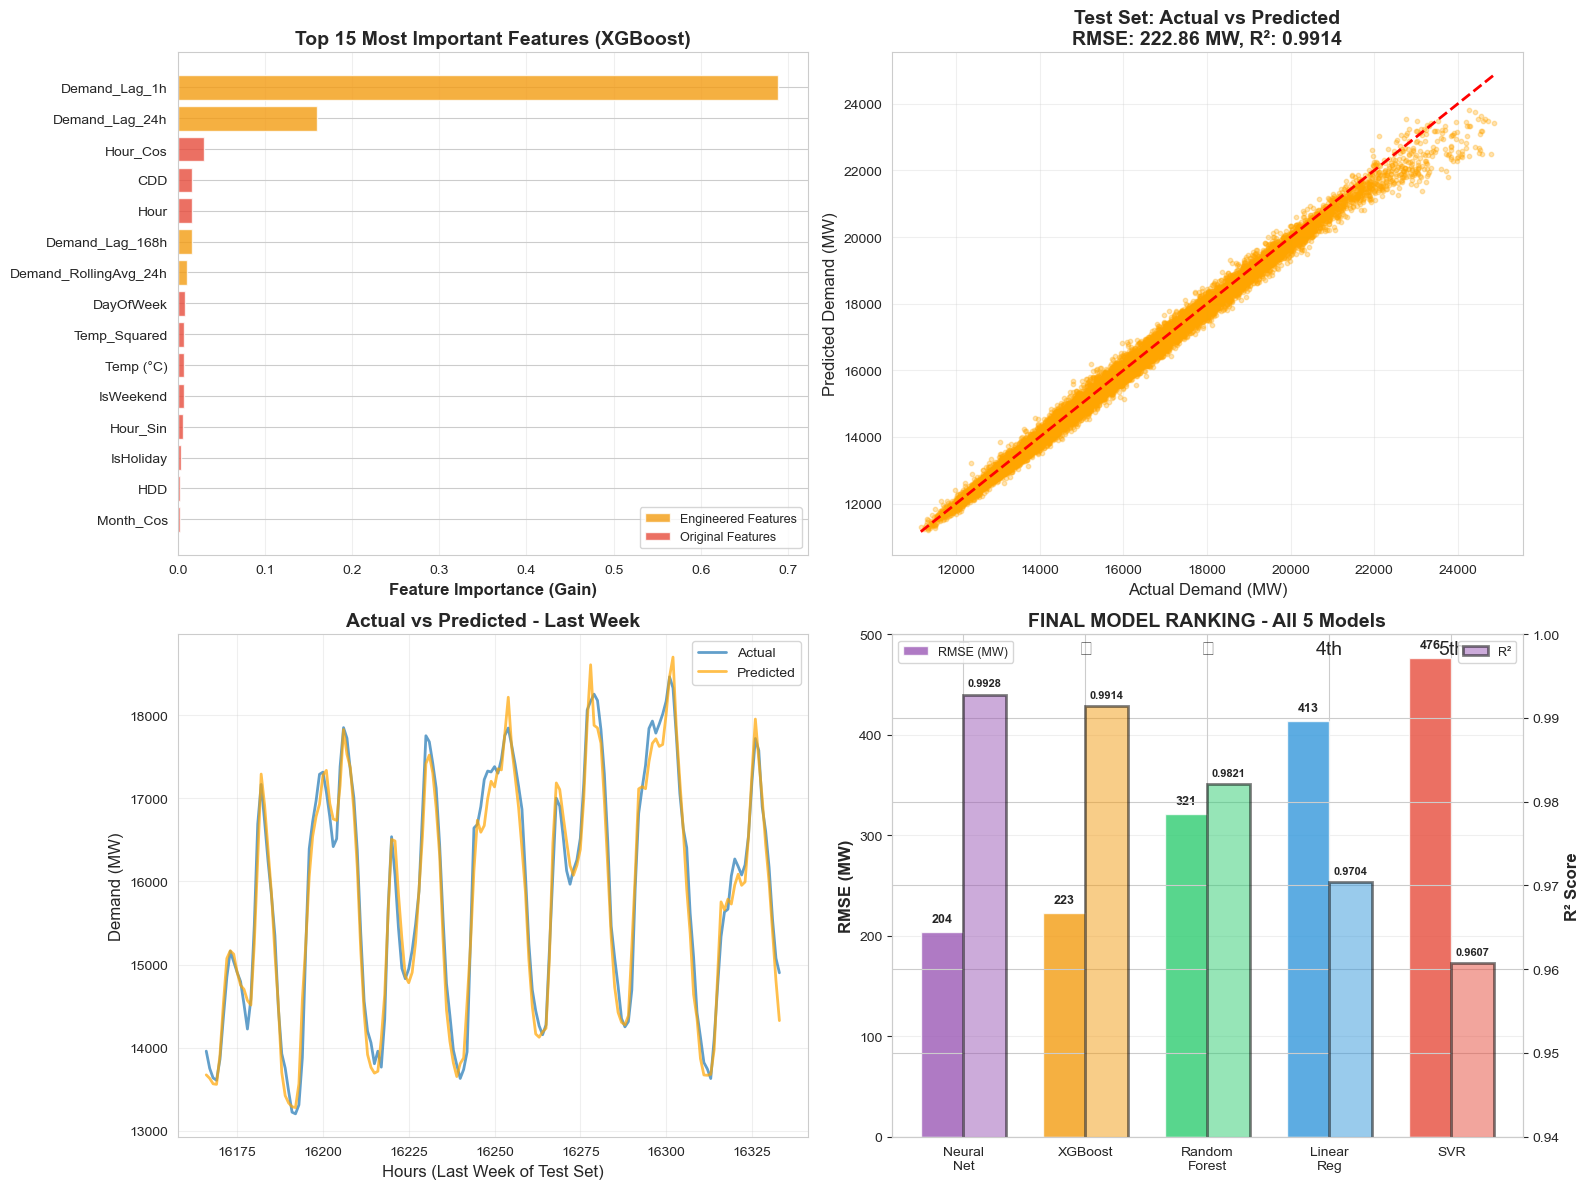


✓ XGBoost visualizations created and saved!

Top 5 Most Important Features:
  14. Demand_Lag_1h: 0.6884
  15. Demand_Lag_24h: 0.1601
  24. Hour_Cos: 0.0304
  20. CDD: 0.0171
  1. Hour: 0.0166


In [7]:
print("Creating XGBoost visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Feature Importance (built-in from XGBoost)
ax1 = axes[0, 0]
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

colors = ['#f39c12' if 'Lag' in f or 'Rolling' in f else '#e74c3c' for f in feature_importance['Feature']]
bars = ax1.barh(range(len(feature_importance)), feature_importance['Importance'], color=colors, alpha=0.8)
ax1.set_yticks(range(len(feature_importance)))
ax1.set_yticklabels(feature_importance['Feature'], fontsize=10)
ax1.set_xlabel('Feature Importance (Gain)', fontsize=12, fontweight='bold')
ax1.set_title('Top 15 Most Important Features (XGBoost)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#f39c12', alpha=0.8, label='Engineered Features'),
    Patch(facecolor='#e74c3c', alpha=0.8, label='Original Features')
]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9)

# 2. Actual vs Predicted
ax2 = axes[0, 1]
ax2.scatter(y_test, y_test_pred, alpha=0.3, s=10, color='orange')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Demand (MW)', fontsize=12)
ax2.set_ylabel('Predicted Demand (MW)', fontsize=12)
ax2.set_title(f'Test Set: Actual vs Predicted\nRMSE: {test_metrics["RMSE"]:.2f} MW, R²: {test_metrics["R2"]:.4f}', 
              fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Time series comparison (last week)
ax3 = axes[1, 0]
sample_size = 168
sample_indices = range(len(y_test) - sample_size, len(y_test))
ax3.plot(sample_indices, y_test.iloc[-sample_size:].values, label='Actual', linewidth=2, alpha=0.7)
ax3.plot(sample_indices, y_test_pred[-sample_size:], label='Predicted', linewidth=2, alpha=0.7, color='orange')
ax3.set_xlabel('Hours (Last Week of Test Set)', fontsize=12)
ax3.set_ylabel('Demand (MW)', fontsize=12)
ax3.set_title('Actual vs Predicted - Last Week', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# 4. Final Model Ranking
ax4 = axes[1, 1]
models = ['Neural\nNet', 'XGBoost', 'Random\nForest', 'Linear\nReg', 'SVR']
rmse_values = [203.92, test_metrics['RMSE'], 321.30, 413.25, 476.05]
r2_values = [0.9928, test_metrics['R2'], 0.9821, 0.9704, 0.9607]
colors = ['#9b59b6', '#f39c12', '#2ecc71', '#3498db', '#e74c3c']

x = np.arange(len(models))
width = 0.35

bars1 = ax4.bar(x - width/2, rmse_values, width, label='RMSE (MW)', color=colors, alpha=0.8)
ax4_twin = ax4.twinx()
bars2 = ax4_twin.bar(x + width/2, r2_values, width, label='R²', color=colors, alpha=0.5, edgecolor='black', linewidth=2)

ax4.set_ylabel('RMSE (MW)', fontsize=12, fontweight='bold')
ax4_twin.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax4.set_title('FINAL MODEL RANKING - All 5 Models', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models, fontsize=10)
ax4.set_ylim([0, 500])
ax4_twin.set_ylim([0.94, 1.0])
ax4.legend(loc='upper left', fontsize=9)
ax4_twin.legend(loc='upper right', fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (rmse, r2) in enumerate(zip(rmse_values, r2_values)):
    ax4.text(i - width/2, rmse + 10, f'{rmse:.0f}', ha='center', fontsize=9, fontweight='bold')
    ax4_twin.text(i + width/2, r2 + 0.001, f'{r2:.4f}', ha='center', fontsize=8, fontweight='bold')

# Add ranking badges
medals = ['🥇', '🥈', '🥉', '4th', '5th']
for i, medal in enumerate(medals):
    ax4.text(i, 480, medal, ha='center', fontsize=14)

plt.tight_layout()
plt.savefig('../../../04_Presentation/model_results/05_xgboost/performance.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ XGBoost visualizations created and saved!")
print(f"\nTop 5 Most Important Features:")
for i, row in feature_importance.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}")

Creating XGBoost-specific visualizations...


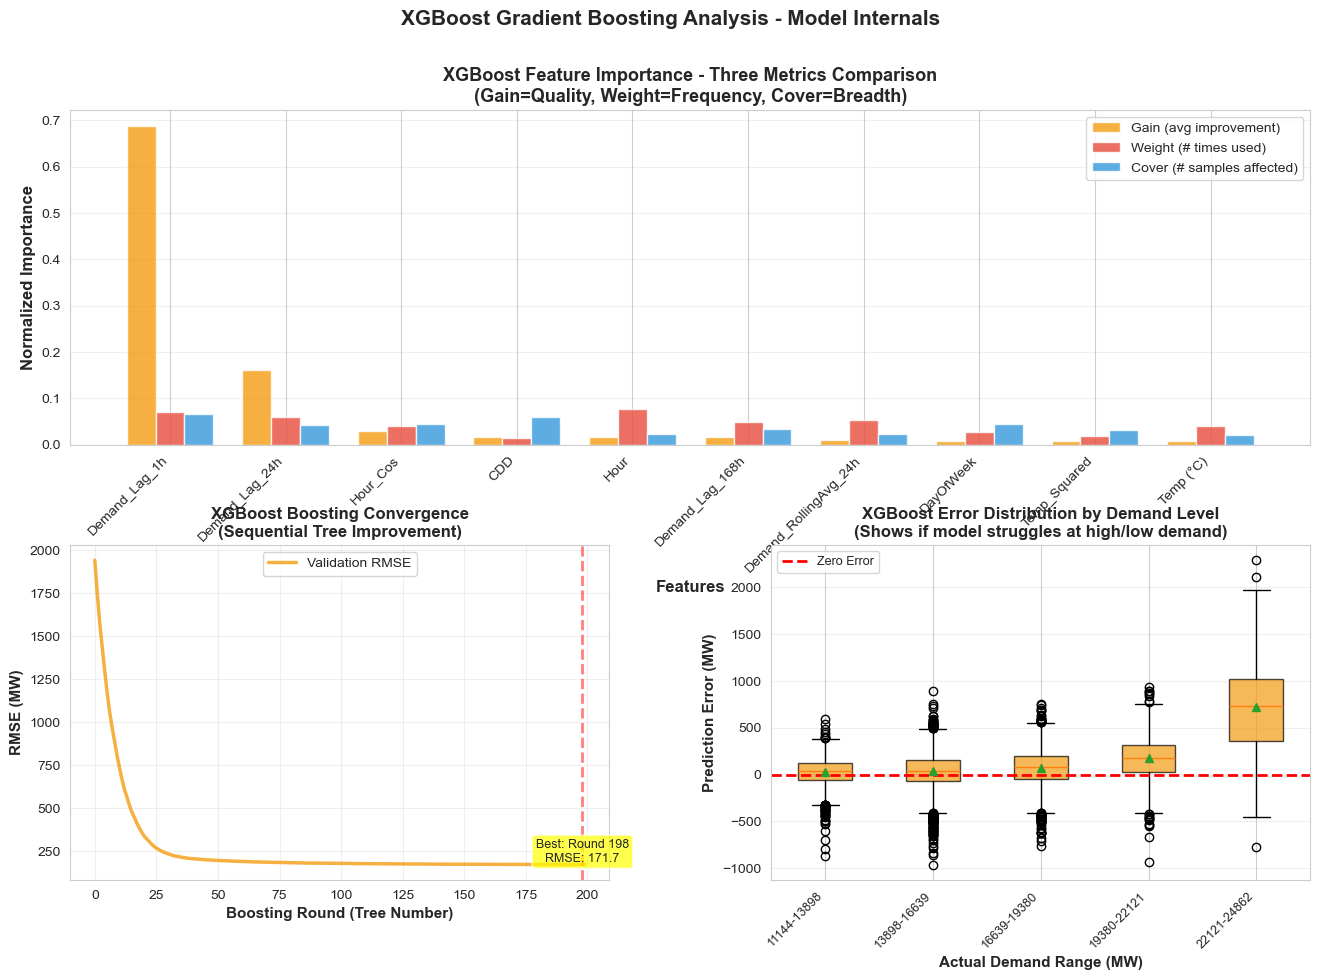


✓ XGBoost detailed analysis created!

Key Insights:
  • Top feature by Gain: Demand_Lag_1h
  • Top feature by Weight: Hour
  • Mean error: 66.61 MW
  • Error std dev: 212.68 MW


In [9]:
print("Creating XGBoost-specific visualizations...")
import xgboost as xgb

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. Feature Importance - Multiple Types
ax1 = fig.add_subplot(gs[0, :])

# Get different importance types
importance_gain = model.get_booster().get_score(importance_type='gain')
importance_weight = model.get_booster().get_score(importance_type='weight')
importance_cover = model.get_booster().get_score(importance_type='cover')

# Create comparison dataframe
importance_df = pd.DataFrame({
    'Feature': list(importance_gain.keys()),
    'Gain': [importance_gain.get(f, 0) for f in importance_gain.keys()],
    'Weight': [importance_weight.get(f, 0) for f in importance_gain.keys()],
    'Cover': [importance_cover.get(f, 0) for f in importance_gain.keys()]
})

# Normalize for comparison
for col in ['Gain', 'Weight', 'Cover']:
    importance_df[col] = importance_df[col] / importance_df[col].sum()

importance_df = importance_df.sort_values('Gain', ascending=False).head(10)

x = np.arange(len(importance_df))
width = 0.25

bars1 = ax1.bar(x - width, importance_df['Gain'], width, label='Gain (avg improvement)', alpha=0.8, color='#f39c12')
bars2 = ax1.bar(x, importance_df['Weight'], width, label='Weight (# times used)', alpha=0.8, color='#e74c3c')
bars3 = ax1.bar(x + width, importance_df['Cover'], width, label='Cover (# samples affected)', alpha=0.8, color='#3498db')

ax1.set_xlabel('Features', fontsize=12, fontweight='bold')
ax1.set_ylabel('Normalized Importance', fontsize=12, fontweight='bold')
ax1.set_title('XGBoost Feature Importance - Three Metrics Comparison\n(Gain=Quality, Weight=Frequency, Cover=Breadth)', 
              fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(importance_df['Feature'], rotation=45, ha='right', fontsize=10)
ax1.legend(fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')

# 2. Boosting Convergence (from eval results)
ax2 = fig.add_subplot(gs[1, 0])
results = model.evals_result()
if results and 'validation_0' in results:
    epochs = len(results['validation_0']['rmse'])
    x_axis = range(0, epochs)
    ax2.plot(x_axis, results['validation_0']['rmse'], label='Validation RMSE', 
             linewidth=2.5, color='#f39c12', alpha=0.8)
    ax2.set_xlabel('Boosting Round (Tree Number)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('RMSE (MW)', fontsize=11, fontweight='bold')
    ax2.set_title('XGBoost Boosting Convergence\n(Sequential Tree Improvement)', 
                  fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    
    # Highlight best iteration
    best_iter = np.argmin(results['validation_0']['rmse'])
    best_rmse = results['validation_0']['rmse'][best_iter]
    ax2.axvline(x=best_iter, color='red', linestyle='--', alpha=0.5, linewidth=2)
    ax2.text(best_iter, best_rmse * 1.1, f'Best: Round {best_iter}\nRMSE: {best_rmse:.1f}',
             ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
else:
    ax2.text(0.5, 0.5, 'Boosting curve not available\n(Model was retrained without eval_set)', 
             ha='center', va='center', fontsize=11, transform=ax2.transAxes)
    ax2.set_title('XGBoost Boosting Process', fontsize=12, fontweight='bold')

# 3. Error Analysis by Prediction Range
ax3 = fig.add_subplot(gs[1, 1])
errors = y_test - y_test_pred
# Bin predictions into ranges
pred_bins = pd.cut(y_test, bins=5)
error_by_bin = pd.DataFrame({'Error': errors, 'Demand_Range': pred_bins})
box_data = [error_by_bin[error_by_bin['Demand_Range'] == cat]['Error'].values 
            for cat in error_by_bin['Demand_Range'].cat.categories]

bp = ax3.boxplot(box_data, labels=[f'{int(cat.left)}-{int(cat.right)}' 
                                    for cat in error_by_bin['Demand_Range'].cat.categories],
                 patch_artist=True, showmeans=True)

for patch in bp['boxes']:
    patch.set_facecolor('#f39c12')
    patch.set_alpha(0.7)

ax3.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax3.set_xlabel('Actual Demand Range (MW)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Prediction Error (MW)', fontsize=11, fontweight='bold')
ax3.set_title('XGBoost Error Distribution by Demand Level\n(Shows if model struggles at high/low demand)', 
              fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

plt.suptitle('XGBoost Gradient Boosting Analysis - Model Internals', 
             fontsize=15, fontweight='bold', y=0.98)

plt.savefig('../../../04_Presentation/model_results/05_xgboost/xgboost_detailed_analysis.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ XGBoost detailed analysis created!")
print("\nKey Insights:")
print(f"  • Top feature by Gain: {importance_df.iloc[0]['Feature']}")
print(f"  • Top feature by Weight: {importance_df.loc[importance_df['Weight'].idxmax(), 'Feature']}")
print(f"  • Mean error: {errors.mean():.2f} MW")
print(f"  • Error std dev: {errors.std():.2f} MW")